# 3. Model Training

## Summary
Train a **CNN-based binary classifier** to detect the presence of a drone from MFCC feature windows.

### Architecture
The network receives tensors of shape **(10, 40, 1)** (10 frames × 40 MFCC coefficients × 1 channel) and outputs a single sigmoid probability.

| Block | Layers |
|---|---|
| Conv Block 1 | Conv2D(32, 3×3) → BN → ReLU → MaxPool(2×2) → Dropout(0.25) |
| Conv Block 2 | Conv2D(64, 3×3) → BN → ReLU → MaxPool(2×2) → Dropout(0.25) |
| Conv Block 3 | Conv2D(128, 3×3) → BN → ReLU → GlobalAvgPool → Dropout(0.4) |
| Head | Dense(256) → BN → ReLU → Dropout(0.5) → Dense(1, sigmoid) |

### Training strategy
- **Optimizer**: Adam (lr = 1e-3, with ReduceLROnPlateau)
- **Loss**: Binary cross-entropy
- **Class weights**: computed from training set to handle imbalance
- **Early stopping**: patience = 15 on validation loss
- **Best model** saved as `best_drone_cnn.keras`


### Imports

In [1]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
os.makedirs("plots", exist_ok=True)

print("TensorFlow version:", tf.__version__)
print("GPU available:", bool(tf.config.list_physical_devices('GPU')))


TensorFlow version: 2.21.0
GPU available: False


## 3.1  Load features

In [2]:
X_train = np.load("X_train.npy")
X_val   = np.load("X_val.npy")
X_test  = np.load("X_test.npy")
y_train = np.load("y_train.npy")
y_val   = np.load("y_val.npy")
y_test  = np.load("y_test.npy")

print(f"X_train : {X_train.shape}  y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}    y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}   y_test  : {y_test.shape}")
print(f"\nLabel balance (train) — drone: {y_train.sum()}, non-drone: {(y_train==0).sum()}")

INPUT_SHAPE = X_train.shape[1:]   # (10, 40, 1)
print(f"\nCNN input shape: {INPUT_SHAPE}")


X_train : (832, 10, 40, 1)  y_train : (832,)
X_val   : (278, 10, 40, 1)    y_val   : (278,)
X_test  : (278, 10, 40, 1)   y_test  : (278,)

Label balance (train) — drone: 292, non-drone: 540

CNN input shape: (10, 40, 1)


## 3.2  Class weights

In [3]:
classes    = np.unique(y_train)
weights    = compute_class_weight("balanced", classes=classes, y=y_train)
class_weights = dict(zip(classes.astype(int), weights))
print("Class weights:", class_weights)


Class weights: {np.int64(0): np.float64(0.7703703703703704), np.int64(1): np.float64(1.4246575342465753)}


## 3.3  Build the CNN

In [4]:
def build_drone_cnn(input_shape, l2_reg=1e-4):
    inputs = keras.Input(shape=input_shape, name="mfcc_input")

    # ── Conv Block 1 ──────────────────────────────────────────────────
    x = layers.Conv2D(32, (3, 3), padding="same",
                      kernel_regularizer=regularizers.l2(l2_reg))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # ── Conv Block 2 ──────────────────────────────────────────────────
    x = layers.Conv2D(64, (3, 3), padding="same",
                      kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # ── Conv Block 3 ──────────────────────────────────────────────────
    x = layers.Conv2D(128, (3, 3), padding="same",
                      kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.40)(x)

    # ── Classification head ──────────────────────────────────────────
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.50)(x)

    outputs = layers.Dense(1, activation="sigmoid", name="drone_prob")(x)

    model = keras.Model(inputs, outputs, name="DroneCNN")
    return model


model = build_drone_cnn(INPUT_SHAPE)
model.summary()


Model: "DroneCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mfcc_input (InputLayer)         │ (None, 10, 40, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 10, 40, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10, 40, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 10, 40, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 5, 20, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 20, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 5, 20, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 5, 20, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 5, 20, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 2, 10, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2, 10, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 2, 10, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 2, 10, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 2, 10, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drone_prob (Dense)              │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,873 (499.50 KB)

 Trainable params: 126,913 (495.75 KB)

 Non-trainable params: 960 (3.75 KB)

AttributeError: 'InputLayer' object has no attribute 'output_shape'

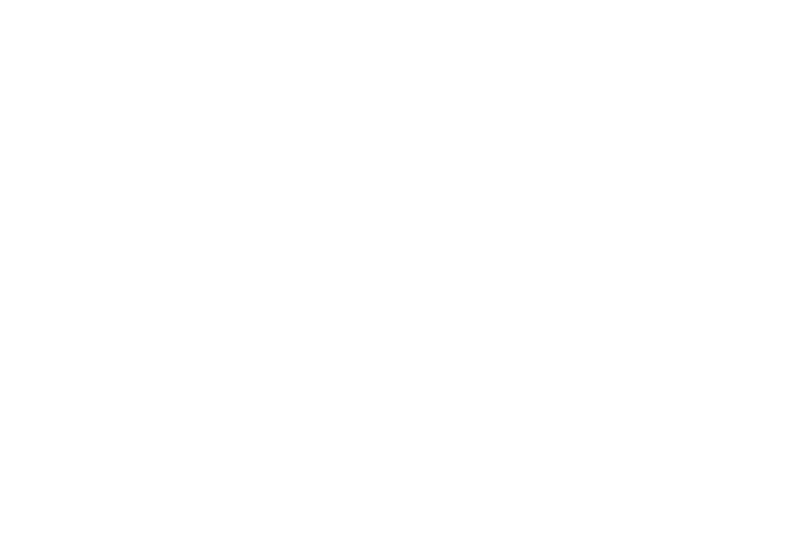

In [6]:
# ── Visualise architecture as a diagram (text table) ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
ax.axis("off")

rows = []
for layer in model.layers:
    out_shape = str(layer.output_shape)
    params    = layer.count_params()
    rows.append([layer.name, layer.__class__.__name__, out_shape, f"{params:,}"])

col_labels = ["Layer name", "Type", "Output shape", "Parameters"]
table = ax.table(cellText=rows, colLabels=col_labels,
                 cellLoc="center", loc="center",
                 bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(8)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor("#2c3e50")
        cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#ecf0f1")
    cell.set_edgecolor("#bdc3c7")

plt.title("DroneCNN Architecture", fontsize=14, fontweight="bold", pad=10)
plt.tight_layout()
plt.savefig("plots/model_architecture.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Total parameters: {model.count_params():,}")


## 3.4  Compile and callbacks

In [7]:
LEARNING_RATE = 1e-3
BATCH_SIZE    = 64
EPOCHS        = 100

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="binary_crossentropy",
    metrics=["accuracy",
             keras.metrics.Precision(name="precision"),
             keras.metrics.Recall(name="recall"),
             keras.metrics.AUC(name="auc")]
)

cb_list = [
    callbacks.EarlyStopping(
        monitor="val_loss", patience=15,
        restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=7, min_lr=1e-6, verbose=1),
    callbacks.ModelCheckpoint(
        "best_drone_cnn.keras",
        monitor="val_loss", save_best_only=True, verbose=1),
    callbacks.CSVLogger("training_log.csv"),
]

print("Compiled. Ready to train.")


Compiled. Ready to train.


## 3.5  Train

In [8]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=cb_list,
    verbose=1,
)


Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6612 - auc: 0.7232 - loss: 0.6378 - precision: 0.5210 - recall: 0.6681
Epoch 1: val_loss improved from None to 0.72687, saving model to best_drone_cnn.keras

Epoch 1: finished saving model to best_drone_cnn.keras
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.7885 - auc: 0.8864 - loss: 0.4493 - precision: 0.6602 - recall: 0.8185 - val_accuracy: 0.3525 - val_auc: 0.9855 - val_loss: 0.7269 - val_precision: 0.3525 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/100
 7/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9592 - auc: 0.9946 - loss: 0.1603 - precision: 0.9226 - recall: 0.9643 
Epoch 2: val_loss did not improve from 0.72687
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9615 - auc: 0.9959 - loss: 0.1365 - precision: 0.9221 - recall: 0.9726 - val_accuracy: 0.3525 - val_auc: 0.9946 - val_loss: 0.8046 - val_precision: 0.3525 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/100
13/13 ━━━━━━━━━━━━

## 3.6  Training curves

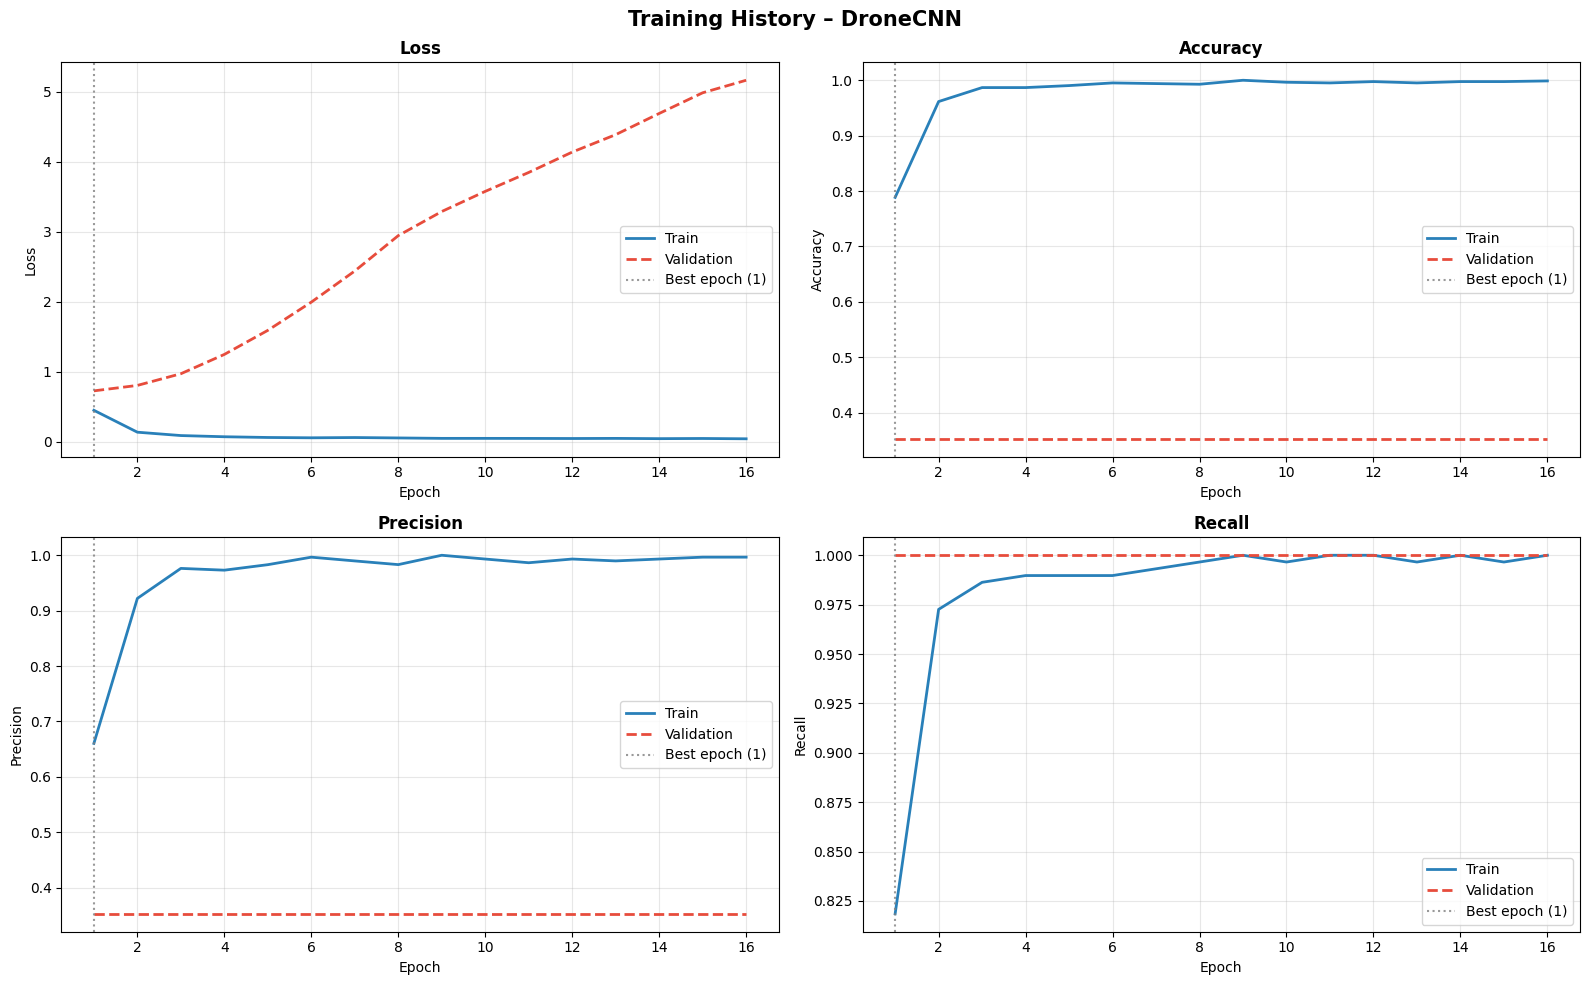

In [9]:
import pandas as pd

log = pd.read_csv("training_log.csv")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Training History – DroneCNN", fontsize=15, fontweight="bold")

metric_pairs = [
    ("loss",      "val_loss",      "Loss",       "Loss"),
    ("accuracy",  "val_accuracy",  "Accuracy",   "Accuracy"),
    ("precision", "val_precision", "Precision",  "Precision"),
    ("recall",    "val_recall",    "Recall",     "Recall"),
]

colors = {"train": "#2980b9", "val": "#e74c3c"}

for ax, (tr_m, val_m, title, ylabel) in zip(axes.flat, metric_pairs):
    ax.plot(log["epoch"] + 1, log[tr_m],  label="Train",      color=colors["train"], linewidth=2)
    ax.plot(log["epoch"] + 1, log[val_m], label="Validation", color=colors["val"],   linewidth=2, linestyle="--")

    best_ep = log[val_m].idxmin() if "loss" in val_m else log[val_m].idxmax()
    ax.axvline(best_ep + 1, color="gray", linestyle=":", alpha=0.8, label=f"Best epoch ({best_ep+1})")

    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("plots/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()


In [10]:
# ── Learning rate schedule ────────────────────────────────────────────────────
if "lr" in log.columns:
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.semilogy(log["epoch"] + 1, log["lr"], color="#8e44ad", linewidth=2)
    ax.set_title("Learning Rate Schedule", fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Learning rate (log scale)")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("plots/lr_schedule.png", dpi=150, bbox_inches="tight")
    plt.show()


## 3.7  Quick validation check

In [11]:
val_loss, val_acc, val_prec, val_rec, val_auc = model.evaluate(X_val, y_val, verbose=0)
print(f"Validation results (best checkpoint)")
print(f"  Loss      : {val_loss:.4f}")
print(f"  Accuracy  : {val_acc*100:.2f}%")
print(f"  Precision : {val_prec*100:.2f}%")
print(f"  Recall    : {val_rec*100:.2f}%")
print(f"  AUC-ROC   : {val_auc:.4f}")


Validation results (best checkpoint)
  Loss      : 0.7269
  Accuracy  : 35.25%
  Precision : 35.25%
  Recall    : 100.00%
  AUC-ROC   : 0.9855


## 3.8  Save training metadata

In [12]:
meta = {
    "input_shape":    list(INPUT_SHAPE),
    "n_mfcc":         40,
    "frame_ms":       200,
    "n_frames":       10,
    "sample_rate":    44100,
    "fmax":           8000,
    "learning_rate":  LEARNING_RATE,
    "batch_size":     BATCH_SIZE,
    "epochs_run":     len(log),
    "val_accuracy":   float(val_acc),
    "val_auc":        float(val_auc),
}
with open("training_meta.json", "w") as f:
    json.dump(meta, f, indent=2)
print("Saved training_meta.json")
print("Saved best_drone_cnn.keras")


Saved training_meta.json
Saved best_drone_cnn.keras
